In [28]:
!pip install optuna 

In [29]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
df.shape

(768, 9)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [32]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [33]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [34]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (537, 8)
Test set shape: (231, 8)


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize

#  The `suggest_*` Methods (Optuna)

| Method | Use for | Example |
|--------|---------|---------|
| `trial.suggest_int('name', low, high)` | Whole numbers | n_estimators, max_depth, batch_size |
| `trial.suggest_float('name', low, high)` | Decimals | learning rate, dropout rate |
| `trial.suggest_float('name', low, high, log=True)` | Decimals across orders of magnitude | learning rate ⭐ |
| `trial.suggest_categorical('name', [list])` | Choose from options | optimizer type, kernel, activation |

---


## Why do we use `log=True` for learning rate?

The **learning rate** can have values like:

```
0.0001
0.001
0.01
0.1
```

These values are **very far apart** (each is 10 times bigger than the previous one).

- **Without `log=True`:**
  - Optuna treats the range normally.
  - It picks **more values near larger numbers** (like 0.01–0.1).
  - Very small values (0.0001, 0.001) are rarely tested.
- **With `log=True`:**
  - Optuna gives **equal importance to every order of magnitude**.
  - It tries values like **0.0001, 0.001, 0.01, and 0.1** more fairly.
  - This increases the chance of finding the best learning rate.

In [36]:
# Create a study object and optimize the objective function
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters  

[I 2026-07-21 13:41:02,766] A new study created in memory with name: no-name-eda42c6f-f304-45e3-9fa8-f2121e0e1d68
[I 2026-07-21 13:41:02,919] Trial 0 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 106, 'max_depth': 20}. Best is trial 0 with value: 0.7746741154562384.
[I 2026-07-21 13:41:03,136] Trial 1 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 160, 'max_depth': 13}. Best is trial 0 with value: 0.7746741154562384.
[I 2026-07-21 13:41:03,230] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 73, 'max_depth': 5}. Best is trial 0 with value: 0.7746741154562384.
[I 2026-07-21 13:41:03,313] Trial 3 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 58, 'max_depth': 18}. Best is trial 0 with value: 0.7746741154562384.
[I 2026-07-21 13:41:03,509] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 140, 'max_depth': 15}. Best is trial 0 with value: 0.7746741

In [37]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7839851024208566
Best hyperparameters: {'n_estimators': 121, 'max_depth': 18}


In [38]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

Test Accuracy with best hyperparameters: 0.74


## Samplers in Optuna

In [39]:
# from sklearn.model_selection import cross_val_score

# # Define the objective function
# def objective(trial):
#     # Suggest values for the hyperparameters
#     n_estimators = trial.suggest_int('n_estimators', 50, 200)
#     max_depth = trial.suggest_int('max_depth', 3, 20)

#     # Create the RandomForestClassifier with suggested hyperparameters
#     model = RandomForestClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         random_state=42
#     )

#     # Perform 3-fold cross-validation and calculate accuracy
#     score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

#     return score  # Return the accuracy score for Optuna to maximize

In [40]:
# study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
# study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

In [41]:
# # Print the best result
# print(f'Best trial accuracy: {study.best_trial.value}')
# print(f'Best hyperparameters: {study.best_trial.params}')

In [42]:
# from sklearn.metrics import accuracy_score

# # Train a RandomForestClassifier using the best hyperparameters from Optuna
# best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# # Fit the model to the training data
# best_model.fit(X_train, y_train)

# # Make predictions on the test set
# y_pred = best_model.predict(X_test)

# # Calculate the accuracy on the test set
# test_accuracy = accuracy_score(y_test, y_pred)

# # Print the test accuracy
# print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

In [43]:
# search_space = {
#     'n_estimators': [50, 100, 150, 200],
#     'max_depth': [5, 10, 15, 20]
# }

In [44]:
# # Create a study and optimize it using GridSampler
# study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
# study.optimize(objective)

In [45]:
# # Print the best result
# print(f'Best trial accuracy: {study.best_trial.value}')
# print(f'Best hyperparameters: {study.best_trial.params}')

In [46]:
# from sklearn.metrics import accuracy_score

# # Train a RandomForestClassifier using the best hyperparameters from Optuna
# best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# # Fit the model to the training data
# best_model.fit(X_train, y_train)

# # Make predictions on the test set
# y_pred = best_model.predict(X_test)

# # Calculate the accuracy on the test set
# test_accuracy = accuracy_score(y_test, y_pred)

# # Print the test accuracy
# print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

# Optuna Visualizations

In [47]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [48]:
# 1. Optimization History
plot_optimization_history(study).show()

In [49]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

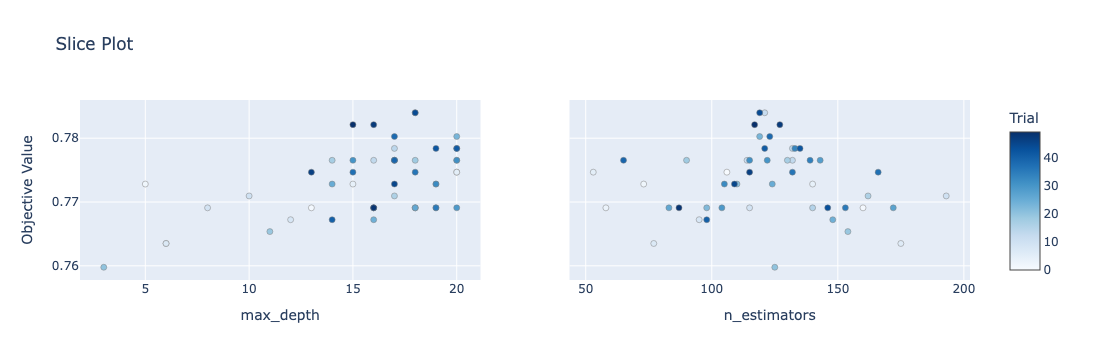

In [50]:
# 3. Slice Plot
plot_slice(study).show()

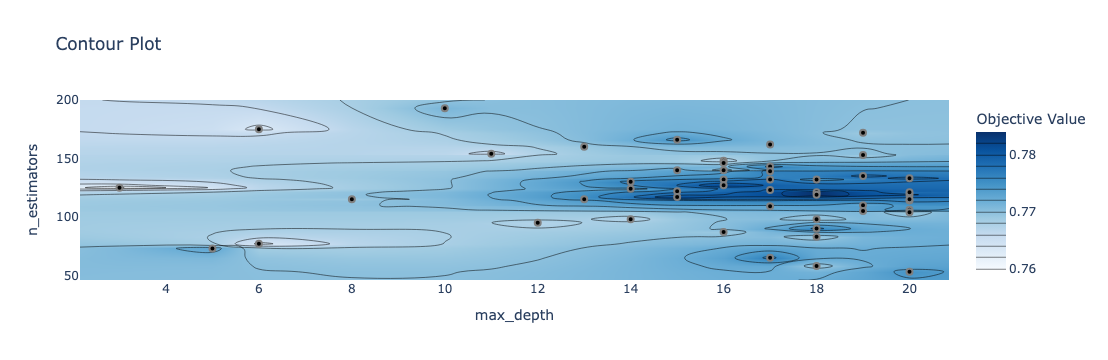

In [51]:
# 4. Contour Plot
plot_contour(study).show()

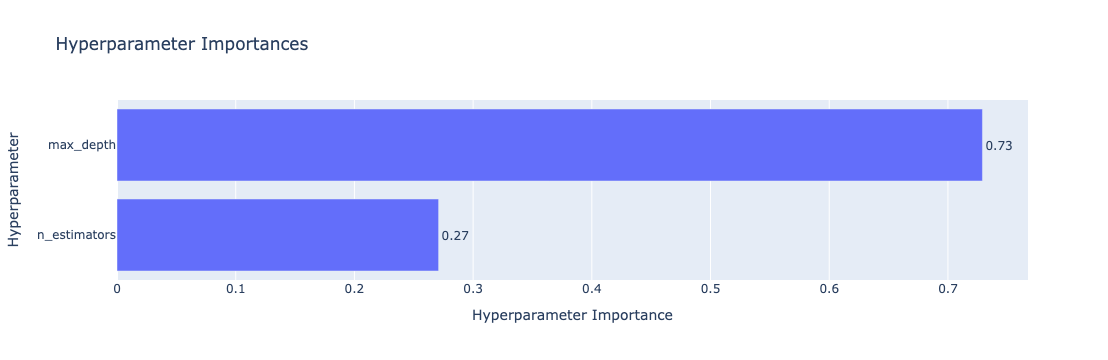

In [52]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()